<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/ResNet_LSTM_Atention_ViVQA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cài đặt thư viện xử lý dataset và thư viện tách từ tiếng Việt
!pip install datasets scikit-learn underthesea matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.2 MB/s eta 0:00:00


In [2]:
#Khai báo thư viện và cấu hình thiết bị
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from underthesea import word_tokenize
import torchvision.models as models

# Tắt chế độ tối ưu cudnn để đảm bảo tính ổn định giống file gốc của bạn
torch.backends.cudnn.enabled = False
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

# Kiểm tra thông số card đồ họa trong môi trường Colab
!nvidia-smi

Đang sử dụng thiết bị: cuda
Fri May 29 13:30:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [3]:
#Cell 3: Tải dữ liệu, xây dựng Từ điển (Vocabulary & Answer Encoder)
# 1. BỘ MÃ HÓA CÂU TRẢ LỜI
class AnswerEncoder:
    def __init__(self):
        self.stoi = {"<UNK>": 0}
        self.itos = {0: "<UNK>"}
        self.idx = 1

    def fit(self, answers):
        for ans in answers:
            if ans not in self.stoi:
                self.stoi[ans] = self.idx
                self.itos[self.idx] = ans
                self.idx += 1

    def encode(self, ans):
        return self.stoi.get(ans, 0)

    def decode(self, idx):
        return self.itos.get(idx, "<UNK>")

    def __len__(self):
        return len(self.stoi)

# 2. TẢI DỮ LIỆU TỪ HUGGING FACE HUB (Cắt nhỏ mẫu giống file gốc để chạy nhanh)
raw_train_ds = load_dataset("ThucPD/coco-qa-vi", split="train[:15000]")
raw_val_ds = load_dataset("ThucPD/coco-qa-vi", split="train[15000:16000]")

print("Đang xây dựng từ điển câu hỏi tiếng Việt...")
word2idx = {"<PAD>": 0, "<UNK>": 1}
for item in raw_train_ds:
    q_text = str(item['translated_question']).lower()
    tokens = word_tokenize(q_text, format="text").split()
    for token in tokens:
        if token not in word2idx:
            word2idx[token] = len(word2idx)

print(f"Tổng kích thước từ điển câu hỏi (Vocab Size): {len(word2idx)}")

ans_encoder = AnswerEncoder()
ans_encoder.fit(raw_train_ds['translated_answer'])
print(f"Số lượng nhãn câu trả lời (Answers): {len(ans_encoder)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.23k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

train/data-00000-of-00026.arrow:   0%|          | 0.00/504M [00:00<?, ?B/s]

train/data-00001-of-00026.arrow:   0%|          | 0.00/500M [00:00<?, ?B/s]

...

test/data-00013-of-00014.arrow:   0%|          | 0.00/462M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Đang xây dựng từ điển câu hỏi tiếng Việt...
Tổng kích thước từ điển câu hỏi (Vocab Size): 3823
Số lượng nhãn câu trả lời (Answers): 411


In [4]:
#Cell 4: Định nghĩa Custom Dataset và Khởi tạo DataLoader
class ResNetLSTMVQADataset(Dataset):
    def __init__(self, hf_dataset, ans_encoder, word2idx, max_length=32, transform=None):
        self.dataset = hf_dataset
        self.ans_encoder = ans_encoder
        self.word2idx = word2idx
        self.max_length = max_length
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # Xử lý ảnh sang định dạng RGB
        image = item['image'].convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Tách từ tiếng Việt cho câu hỏi
        q_text = str(item['translated_question']).lower()
        tokens = word_tokenize(q_text, format="text").split()

        # Chuyển chữ thành danh sách ID số
        input_ids = [self.word2idx.get(t, self.word2idx["<UNK>"]) for t in tokens]
        length = min(len(input_ids), self.max_length)

        # Padding / Truncation thủ công cho chuỗi văn bản
        if len(input_ids) < self.max_length:
            input_ids += [self.word2idx["<PAD>"]] * (self.max_length - len(input_ids))
        else:
            input_ids = input_ids[:self.max_length]

        return (
            image,
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(self.ans_encoder.encode(item['translated_answer']), dtype=torch.long)
        )

# Phép biến đổi chuẩn hóa ảnh đầu vào cho ResNet50 pre-trained
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def vqa_collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    input_ids = torch.stack([item[1] for item in batch])
    lengths = torch.stack([item[2] for item in batch])
    labels = torch.stack([item[3] for item in batch])
    return images, input_ids, lengths, labels

# Tạo các bộ Loader dữ liệu
train_dataset = ResNetLSTMVQADataset(raw_train_ds, ans_encoder, word2idx, max_length=32, transform=img_transform)
val_dataset = ResNetLSTMVQADataset(raw_val_ds, ans_encoder, word2idx, max_length=32, transform=img_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=vqa_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=vqa_collate_fn)

print(f"Khởi tạo DataLoader thành công. Số batch Train: {len(train_loader)}")

Khởi tạo DataLoader thành công. Số batch Train: 938


In [5]:
#Cell 5:Thiết lập Kiến trúc Mô hình (ResNet50 + LSTM) và Cấu hình Huấn luyện
class ResNetLSTMVQA(nn.Module):
    def __init__(self, vocab_size, num_classes, embed_dim=256, hidden_dim=512):
        super(ResNetLSTMVQA, self).__init__()

        # 1. Image Backbone: ResNet50
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for param in resnet.parameters():
            param.requires_grad = False # Khóa trọng số CNN gốc

        num_ftrs = resnet.fc.in_features
        self.resnet_backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.img_fc = nn.Linear(num_ftrs, 768) # Đưa về không gian 768 chiều tương thích

        # 2. Text Backbone: Embedding + LSTM Bi-directional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.text_fc = nn.Linear(hidden_dim * 2, 768)

        # 3. Classifier kết hợp đa phương tiện (Giữ nguyên cấu trúc phân tầng như file gốc)
        self.classifier = nn.Sequential(
            nn.Linear(768 + 768, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(1024, num_classes)
        )

    def forward(self, images, input_ids, lengths):
        # Trích xuất đặc trưng ảnh
        with torch.no_grad():
            img_feats = self.resnet_backbone(images)
        img_feats = torch.flatten(img_feats, 1)
        img_features = self.img_fc(img_feats)

        # Trích xuất đặc trưng văn bản bằng LSTM kết hợp pack_padded_sequence
        embedded = self.embedding(input_ids)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, cell) = self.lstm(packed_embedded)

        # Ghép trạng thái ẩn của chiều xuôi và chiều ngược
        hidden_last = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        text_features = self.text_fc(hidden_last)

        # Ghép đặc trưng Ảnh + Chữ (Concatenate)
        combined = torch.cat((img_features, text_features), dim=1)
        return self.classifier(combined)

# Hàm phụ trợ tính toán các độ đo hiệu suất (Metrics)
def calculate_metrics(preds, labels):
    pred_classes = torch.argmax(preds, dim=1).cpu().numpy()
    labels = labels.cpu().numpy()
    acc = accuracy_score(labels, pred_classes)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, pred_classes, average='macro', zero_division=0
    )
    return acc, precision, recall, f1

# Khởi tạo mô hình, hàm mất mát và bộ tối ưu hóa
model = ResNetLSTMVQA(vocab_size=len(word2idx), num_classes=len(ans_encoder)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=0.01)

num_epochs = 10
history = {
    'train_loss': [], 'val_loss': [],
    'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}
best_val_loss = float('inf')
print("Mô hình đã sẵn sàng để huấn luyện!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 99.1MB/s]


Mô hình đã sẵn sàng để huấn luyện!


--- KHỞI CHẠY HUẤN LUYỆN (TRAINING) ---


Epoch 1/10 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

--> [SAVE] Đã lưu mô hình tốt nhất tại Epoch 1 với Val Loss: 2.3212
Epoch [1/10] | Train Loss: 3.0149 | Val Loss: 2.3212 | Acc: 0.4425 | F1: 0.2944


Epoch 2/10 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch [9/10] | Train Loss: 0.2257 | Val Loss: 2.7925 | Acc: 0.4802 | F1: 0.3269


Epoch 10/10 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch [10/10] | Train Loss: 0.1706 | Val Loss: 3.0593 | Acc: 0.4643 | F1: 0.3138


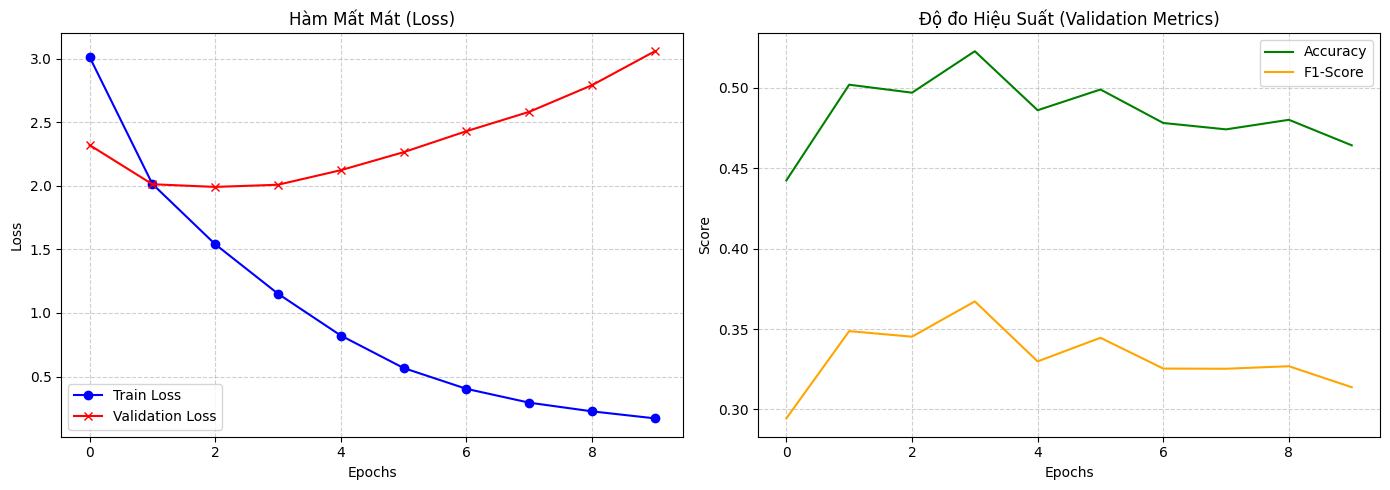

In [6]:
#Cell 6: Huấn luyện Mô hình & Vẽ biểu đồ Loss/Metrics
print("--- KHỞI CHẠY HUẤN LUYỆN (TRAINING) ---")
for epoch in range(num_epochs):
    # ---- PHASE: TRAIN ----
    model.train()
    train_loss = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

    for images, input_ids, lengths, labels in train_loop:
        images, input_ids, labels = images.to(device), input_ids.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, lengths)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Ổn định LSTM tránh bùng nổ grad
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # ---- PHASE: VALIDATION ----
    model.eval()
    val_loss, val_acc, val_prec, val_rec, val_f1 = 0, 0, 0, 0, 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, input_ids, lengths, labels in val_loop:
            images, input_ids, labels = images.to(device), input_ids.to(device), labels.to(device)

            outputs = model(images, input_ids, lengths)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            acc, prec, rec, f1 = calculate_metrics(outputs, labels)
            val_acc += acc
            val_prec += prec
            val_rec += rec
            val_f1 += f1

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)
    avg_val_prec = val_prec / len(val_loader)
    avg_val_rec = val_rec / len(val_loader)
    avg_val_f1 = val_f1 / len(val_loader)

    # Lưu mô hình tốt nhất dựa trên hàm Loss tập Validation
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_vqa_model.pth')
        print(f"--> [SAVE] Đã lưu mô hình tốt nhất tại Epoch {epoch+1} với Val Loss: {avg_val_loss:.4f}")

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    history['val_precision'].append(avg_val_prec)
    history['val_recall'].append(avg_val_rec)
    history['val_f1'].append(avg_val_f1)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Acc: {avg_val_acc:.4f} | F1: {avg_val_f1:.4f}")

# ---- TRỰC QUAN HÓA KẾT QUẢ ĐỒ THỊ ----
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='red', marker='x')
plt.title('Hàm Mất Mát (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Accuracy', color='green')
plt.plot(history['val_f1'], label='F1-Score', color='orange')
plt.title('Độ đo Hiệu Suất (Validation Metrics)')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [7]:
from google.colab import files

# Lệnh ép Google Colab gửi file về trình duyệt của bạn
print("Đang chuẩn bị tải file mô hình tốt nhất xuống máy tính...")
files.download('best_vqa_model.pth')

Đang chuẩn bị tải file mô hình tốt nhất xuống máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

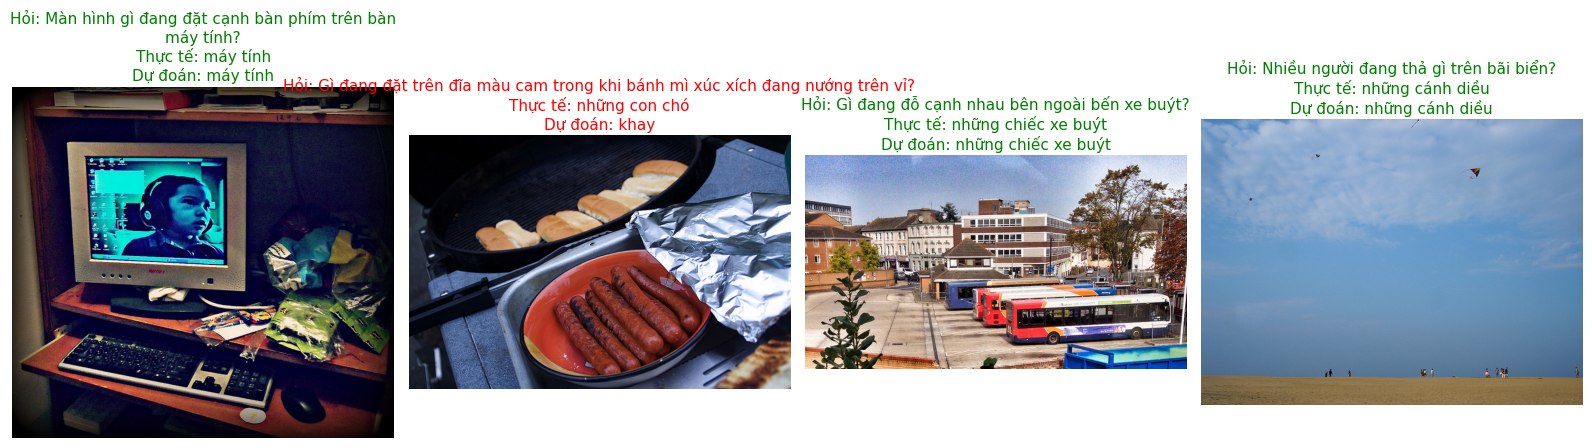

In [9]:
#Cell 7: Kiểm tra Dự đoán thực tế trên 4 ảnh ngẫu nhiên
# Chuyển mô hình sang chế độ đánh giá (Inference)
model.eval()

# Trích xuất 1 batch từ bộ dữ liệu validation để test
images, input_ids, lengths, labels = next(iter(val_loader))
images, input_ids = images.to(device), input_ids.to(device)

with torch.no_grad():
    outputs = model(images, input_ids, lengths)
    predicted = torch.argmax(outputs, dim=1)

# Tiến hành vẽ hình ảnh và so sánh kết quả dự đoán
num_examples = 4
plt.figure(figsize=(16, 6))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    img = raw_val_ds[i]['image'].convert("RGB")
    plt.imshow(img)
    plt.axis('off')

    q_text = raw_val_ds[i]['translated_question']
    true_ans = ans_encoder.decode(labels[i].item())
    pred_ans = ans_encoder.decode(predicted[i].item())

    title = f"Hỏi: {q_text}\nThực tế: {true_ans}\nDự đoán: {pred_ans}"
    color = 'green' if true_ans == pred_ans else 'red'
    plt.title(title, color=color, fontsize=11, wrap=True)

plt.tight_layout()
plt.show()

In [16]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
from underthesea import word_tokenize
import matplotlib.pyplot as plt

def predict_vqa_any_image(image_path, question_text, model, word2idx, ans_encoder, max_length=32):
    """
    Hàm xử lý và dự đoán câu trả lời cho mô hình ResNet50 + LSTM cơ bản
    """
    # 1. Chuyển mô hình sang chế độ đánh giá (Inference)
    model.eval()

    # 2. Kiểm tra và tải ảnh đầu vào
    if not os.path.exists(image_path):
        print(f"❌ LỖI: Không tìm thấy file ảnh tại đường dẫn '{image_path}'.")
        print("💡 Hướng dẫn: Bạn hãy kéo thả ảnh vào menu Files (biểu tượng Thư mục bên trái Colab) rồi kiểm tra lại tên file.")
        return

    try:
        raw_image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"❌ LỖI: Không thể mở được file ảnh. Chi tiết: {e}")
        return

    # Chuẩn hóa ảnh y hệt như lúc huấn luyện
    img_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = img_transform(raw_image).unsqueeze(0).to(device) # Thêm chiều batch -> (1, 3, 224, 224)

    # 3. Tiền xử lý câu hỏi tiếng Việt
    q_text = str(question_text).lower().strip()
    # Tách từ tiếng Việt bằng underthesea (Ví dụ: "áo màu đỏ" -> ["áo", "màu_đỏ"])
    tokens = word_tokenize(q_text, format="text").split()

    # Chuyển chữ thành số ID dựa trên từ điển word2idx đã có lúc train
    input_ids = [word2idx.get(t, word2idx["<UNK>"]) for t in tokens]
    length = min(len(input_ids), max_length)

    # Padding hoặc cắt ngắn chuỗi cho đúng độ dài max_length
    if len(input_ids) < max_length:
        input_ids += [word2idx["<PAD>"]] * (max_length - len(input_ids))
    else:
        input_ids = input_ids[:max_length]

    input_ids_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    length_tensor = torch.tensor([length], dtype=torch.long).to(device)

    # 4. Đưa qua mô hình để dự đoán
    with torch.no_grad():
        outputs = model(image_tensor, input_ids_tensor, length_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()

    # 5. Dịch mã kết quả từ Số ngược lại thành Chữ tiếng Việt
    predicted_answer = ans_encoder.decode(pred_idx)

    # 6. Vẽ ảnh và hiển thị kết quả trực quan
    plt.figure(figsize=(6, 5))
    plt.imshow(raw_image)
    plt.axis('off')
    plt.title(f"❓ Câu hỏi: {question_text}\n🎯 Mô hình đoán: {predicted_answer}",
              fontsize=12, color='darkgreen', fontweight='bold', loc='center', wrap=True)
    plt.show()

    return predicted_answer



✅ Thành công: Đã load trọng số tối ưu từ file 'best_vqa_model.pth'.

--- 🚀 ĐANG KHỞI CHẠY DỰ ĐOÁN THỰC TẾ ---


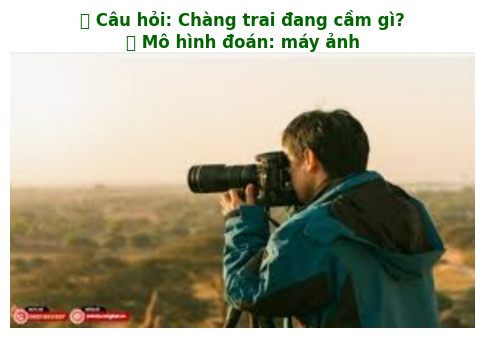

'máy ảnh'

In [22]:
# =====================================================================
# 🛠️ KHU VỰC ĐIỀU KHIỂN & CHẠY THỬ NGHIỆM ĐỘC LẬP
# =====================================================================

# CẤU HÌNH ĐƯỜNG DẪN THỰC TẾ CỦA BẠN TẠI ĐÂY:
FILE_ANH_CUA_BAN = "1.jpg"      # <-- Thay bằng tên file ảnh bạn đã up lên Colab
CAU_HOI_CUA_BAN = "Chàng trai đang cầm gì?" # <-- Thay bằng câu hỏi bạn muốn hỏi mô hình

MODEL_PATH = 'best_vqa_model.pth'

# BƯỚC NẠP (LOAD) MÔ HÌNH:
if os.path.exists(MODEL_PATH):
    try:
        # Load trọng số từ file .pth vào kiến trúc mạng hiện tại
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print(f"✅ Thành công: Đã load trọng số tối ưu từ file '{MODEL_PATH}'.")
    except Exception as e:
        print(f"⚠️ Cảnh báo lỗi khi load file .pth: {e}. Hệ thống sẽ dùng mô hình hiện tại trên RAM.")
else:
    print(f"⚠️ Cảnh báo: Không tìm thấy file '{MODEL_PATH}' trên ổ đĩa Colab.")
    print("Mô hình sẽ sử dụng trực tiếp trọng số đang có sẵn trên RAM (từ lượt chạy Train vừa xong).")

print("\n--- 🚀 ĐANG KHỞI CHẠY DỰ ĐOÁN THỰC TẾ ---")
predict_vqa_any_image(FILE_ANH_CUA_BAN, CAU_HOI_CUA_BAN, model, word2idx, ans_encoder)

THÊM CƠ CHẾ TỰ CHÚ Ý

In [10]:
#Cell 4: Định nghĩa Custom Dataset và Khởi tạo DataLoader. Tăng batch size lên 64
class ResNetLSTMVQADataset(Dataset):
    def __init__(self, hf_dataset, ans_encoder, word2idx, max_length=32, transform=None):
        self.dataset = hf_dataset
        self.ans_encoder = ans_encoder
        self.word2idx = word2idx
        self.max_length = max_length
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # Xử lý ảnh sang định dạng RGB
        image = item['image'].convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Tách từ tiếng Việt cho câu hỏi
        q_text = str(item['translated_question']).lower()
        tokens = word_tokenize(q_text, format="text").split()

        # Chuyển chữ thành danh sách ID số
        input_ids = [self.word2idx.get(t, self.word2idx["<UNK>"]) for t in tokens]
        length = min(len(input_ids), self.max_length)

        # Padding / Truncation thủ công cho chuỗi văn bản
        if len(input_ids) < self.max_length:
            input_ids += [self.word2idx["<PAD>"]] * (self.max_length - len(input_ids))
        else:
            input_ids = input_ids[:self.max_length]

        return (
            image,
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(self.ans_encoder.encode(item['translated_answer']), dtype=torch.long)
        )

# Phép biến đổi chuẩn hóa ảnh đầu vào cho ResNet50 pre-trained
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def vqa_collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    input_ids = torch.stack([item[1] for item in batch])
    lengths = torch.stack([item[2] for item in batch])
    labels = torch.stack([item[3] for item in batch])
    return images, input_ids, lengths, labels

# Tạo các bộ Loader dữ liệu
train_dataset = ResNetLSTMVQADataset(raw_train_ds, ans_encoder, word2idx, max_length=32, transform=img_transform)
val_dataset = ResNetLSTMVQADataset(raw_val_ds, ans_encoder, word2idx, max_length=32, transform=img_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=vqa_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=vqa_collate_fn)

print(f"Khởi tạo DataLoader thành công. Số batch Train: {len(train_loader)}")

Khởi tạo DataLoader thành công. Số batch Train: 235


In [11]:
#Cell 5: cách 2
class VisualAttention(nn.Module):
    def __init__(self, img_dim=2048, text_dim=1024, attn_dim=512):
        super(VisualAttention, self).__init__()
        self.img_proj = nn.Linear(img_dim, attn_dim)
        self.text_proj = nn.Linear(text_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1)

    def forward(self, img_features, text_features):
        # img_features: [batch_size, num_features, img_dim] -> (B, 49, 2048) từ các vùng ảnh
        # text_features: [batch_size, text_dim] -> (B, 1024) từ trạng thái ẩn của LSTM

        num_features = img_features.size(1)

        # Chiếu cả 2 đặc trưng về cùng không gian ẩn (attn_dim)
        img_p = self.img_proj(img_features) # [B, 49, attn_dim]
        text_p = self.text_proj(text_features).unsqueeze(1) # [B, 1, attn_dim]

        # Kết hợp (Bahdanau Attention)
        scores = self.v(torch.tanh(img_p + text_p)).squeeze(-1) # [B, 49]

        # Tính toán trọng số Attention bằng Softmax
        attn_weights = torch.softmax(scores, dim=1) # [B, 49]

        # Tính vector ngữ cảnh tổng hợp từ ảnh dựa trên sự chú ý
        context = torch.bmm(attn_weights.unsqueeze(1), img_features).squeeze(1) # [B, img_dim]
        return context, attn_weights

class ResNetAttentionLSTM_VQA(nn.Module):
    def __init__(self, vocab_size, num_classes, embed_dim=256, hidden_dim=512):
        super(ResNetAttentionLSTM_VQA, self).__init__()

        # 1. Image Backbone: Lấy các bản đồ đặc trưng dạng lưới (Grid features) của ResNet50
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for param in resnet.parameters():
            param.requires_grad = False

        # Bỏ lớp Layer cuối (fc) và lớp Pooling trung bình (avgpool) để lấy ma trận đặc trưng không gian 7x7
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-2])

        # 2. Text Backbone: LSTM Bi-directional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # 3. Cơ chế Attention kết hợp Đa phương tiện
        self.attention = VisualAttention(img_dim=2048, text_dim=hidden_dim * 2, attn_dim=512)

        # 4. Bộ phân loại Classifier cuối cùng
        self.classifier = nn.Sequential(
            nn.Linear(2048 + (hidden_dim * 2), 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.5), # Tăng dropout lên 0.5 để chống Overfitting
            nn.Linear(1024, num_classes)
        )

    def forward(self, images, input_ids, lengths):
        # Trích xuất đặc trưng không gian ảnh: [B, 3, 224, 224] -> [B, 2048, 7, 7]
        with torch.no_grad():
            img_grid = self.resnet_features(images)
        # Biến đổi ma trận 7x7 thành chuỗi 49 vùng ảnh: [B, 2048, 49] -> [B, 49, 2048]
        img_features = img_grid.flatten(2).permute(0, 2, 1)

        # Trích xuất đặc trưng câu hỏi từ LSTM
        embedded = self.embedding(input_ids)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        text_features = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1) # [B, hidden_dim * 2]

        # Áp dụng cơ chế Attention để tìm vùng ảnh tương ứng câu hỏi
        attended_img_features, attn_weights = self.attention(img_features, text_features)

        # Ghép đặc trưng ảnh đã được "chú ý" với đặc trưng chữ
        combined = torch.cat((attended_img_features, text_features), dim=1)
        return self.classifier(combined)

# (Phần định nghĩa loss, optimizer giữ nguyên nhưng bạn nhớ tăng Batch Size lên 64 ở Cell 4 nhé!)
model = ResNetAttentionLSTM_VQA(vocab_size=len(word2idx), num_classes=len(ans_encoder)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=0.01)

num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}
best_val_loss = float('inf')
print("Mô hình ResNet + LSTM + ATTENTION đã sẵn sàng!")

Mô hình ResNet + LSTM + ATTENTION đã sẵn sàng!


--- KHỞI CHẠY HUẤN LUYỆN (TRAINING) ---


Epoch 1/10 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

--> [SAVE] Đã lưu mô hình tốt nhất tại Epoch 1 với Val Loss: 2.3382
Epoch [1/10] | Train Loss: 3.2295 | Val Loss: 2.3382 | Acc: 0.4541 | F1: 0.3025


Epoch 2/10 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [9/10] | Train Loss: 0.1222 | Val Loss: 2.3437 | Acc: 0.4971 | F1: 0.3491


Epoch 10/10 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [10/10] | Train Loss: 0.0895 | Val Loss: 2.4404 | Acc: 0.4996 | F1: 0.3555


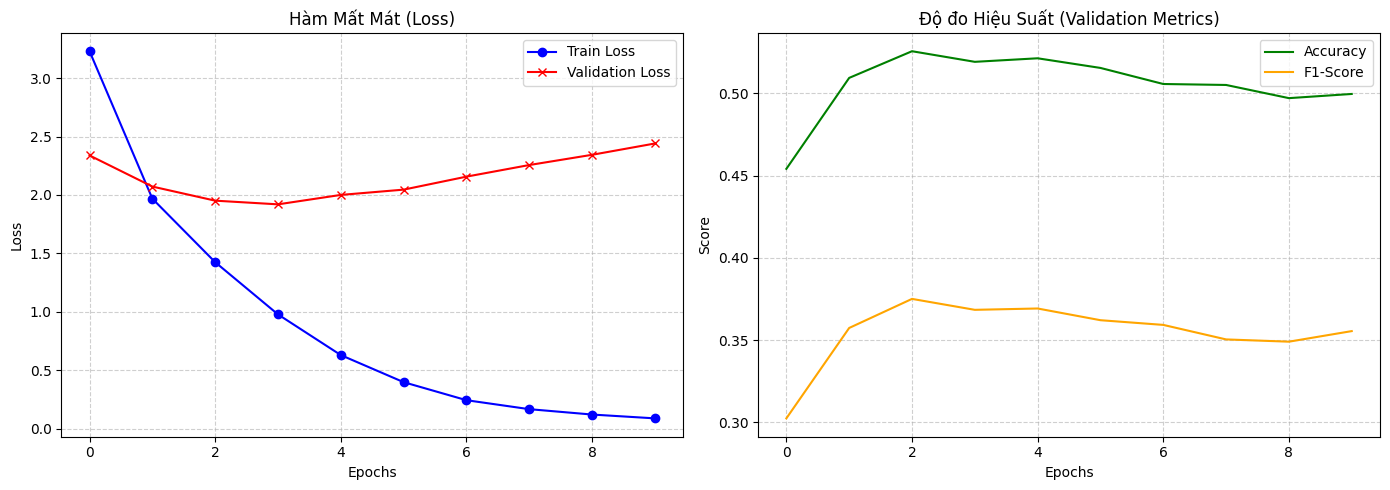

In [12]:
#Cell 6: Huấn luyện Mô hình & Vẽ biểu đồ Loss/Metrics
print("--- KHỞI CHẠY HUẤN LUYỆN (TRAINING) ---")
for epoch in range(num_epochs):
    # ---- PHASE: TRAIN ----
    model.train()
    train_loss = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

    for images, input_ids, lengths, labels in train_loop:
        images, input_ids, labels = images.to(device), input_ids.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, lengths)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Ổn định LSTM tránh bùng nổ grad
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # ---- PHASE: VALIDATION ----
    model.eval()
    val_loss, val_acc, val_prec, val_rec, val_f1 = 0, 0, 0, 0, 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, input_ids, lengths, labels in val_loop:
            images, input_ids, labels = images.to(device), input_ids.to(device), labels.to(device)

            outputs = model(images, input_ids, lengths)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            acc, prec, rec, f1 = calculate_metrics(outputs, labels)
            val_acc += acc
            val_prec += prec
            val_rec += rec
            val_f1 += f1

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)
    avg_val_prec = val_prec / len(val_loader)
    avg_val_rec = val_rec / len(val_loader)
    avg_val_f1 = val_f1 / len(val_loader)

    # Lưu mô hình tốt nhất dựa trên hàm Loss tập Validation
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_vqa_model.pth')
        print(f"--> [SAVE] Đã lưu mô hình tốt nhất tại Epoch {epoch+1} với Val Loss: {avg_val_loss:.4f}")

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    history['val_precision'].append(avg_val_prec)
    history['val_recall'].append(avg_val_rec)
    history['val_f1'].append(avg_val_f1)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Acc: {avg_val_acc:.4f} | F1: {avg_val_f1:.4f}")

# ---- TRỰC QUAN HÓA KẾT QUẢ ĐỒ THỊ ----
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='red', marker='x')
plt.title('Hàm Mất Mát (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Accuracy', color='green')
plt.plot(history['val_f1'], label='F1-Score', color='orange')
plt.title('Độ đo Hiệu Suất (Validation Metrics)')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [13]:
from google.colab import files

# Lệnh ép Google Colab gửi file về trình duyệt của bạn
print("Đang chuẩn bị tải file mô hình tốt nhất xuống máy tính...")
files.download('best_vqa_model.pth')

Đang chuẩn bị tải file mô hình tốt nhất xuống máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

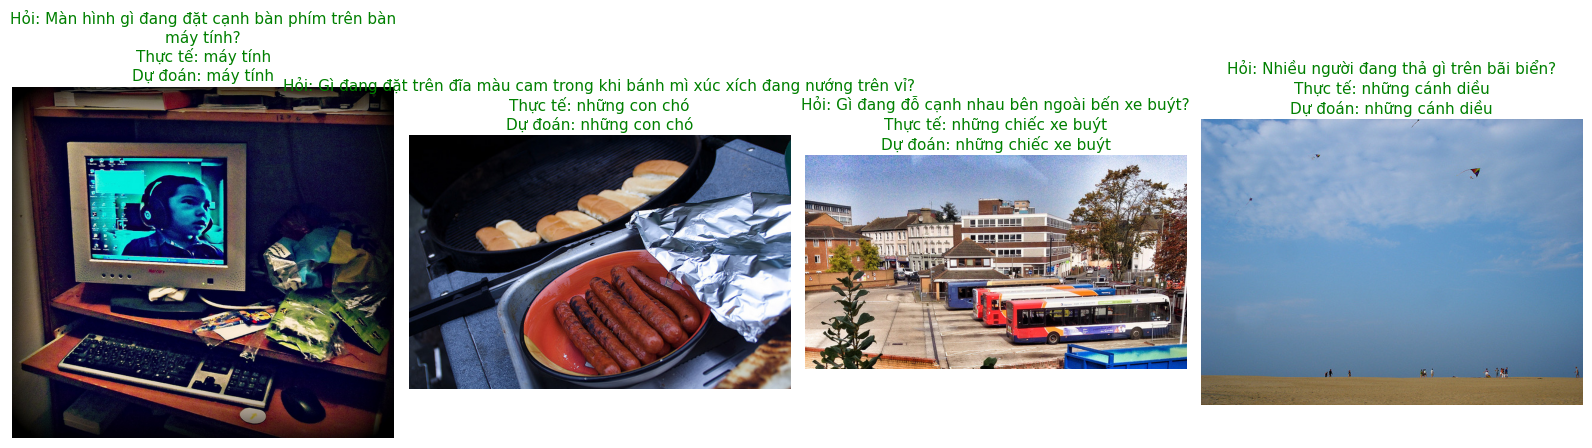

In [14]:
#Cell 7: Kiểm tra Dự đoán thực tế trên 4 ảnh ngẫu nhiên
# Chuyển mô hình sang chế độ đánh giá (Inference)
model.eval()

# Trích xuất 1 batch từ bộ dữ liệu validation để test
images, input_ids, lengths, labels = next(iter(val_loader))
images, input_ids = images.to(device), input_ids.to(device)

with torch.no_grad():
    outputs = model(images, input_ids, lengths)
    predicted = torch.argmax(outputs, dim=1)

# Tiến hành vẽ hình ảnh và so sánh kết quả dự đoán
num_examples = 4
plt.figure(figsize=(16, 6))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    img = raw_val_ds[i]['image'].convert("RGB")
    plt.imshow(img)
    plt.axis('off')

    q_text = raw_val_ds[i]['translated_question']
    true_ans = ans_encoder.decode(labels[i].item())
    pred_ans = ans_encoder.decode(predicted[i].item())

    title = f"Hỏi: {q_text}\nThực tế: {true_ans}\nDự đoán: {pred_ans}"
    color = 'green' if true_ans == pred_ans else 'red'
    plt.title(title, color=color, fontsize=11, wrap=True)

plt.tight_layout()
plt.show()